<a href="https://colab.research.google.com/github/Jaksi-ka/Resume-Screening-System-using-NLP/blob/main/final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# Install required libraries for NLP, Machine Learning, and BERT
!pip install transformers datasets torch scikit-learn nltk pandas numpy seaborn matplotlib -q

import os
import re
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("All libraries successfully installed and loaded!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


All libraries successfully installed and loaded!


[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [15]:
import os
import zipfile
import pandas as pd

zip_filename = "archive (5).zip"
extract_dir = "./extracted_resumes"
df = None

# 1. Attempt to extract 'archive (5).zip' if uploaded and valid
if os.path.exists(zip_filename) and zipfile.is_zipfile(zip_filename):
    print(f"Found '{zip_filename}'. Attempting extraction...")
    try:
        with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)

        # Locate extracted CSV file
        for root, dirs, files in os.walk(extract_dir):
            for file in files:
                if file.endswith(".csv"):
                    df = pd.read_csv(os.path.join(root, file))
                    print(f"Successfully loaded CSV from ZIP: {file}")
                    break

    except Exception as e:
        print(f"⚠️ Extraction failed: {e}")
        print("Switching to direct dataset fallback...")

# 2. Fallback to direct dataset loading if zip was missing, corrupted, or failed to extract
if df is None:
    print("Loading primary resume dataset from source URL...")
    dataset_url = "https://raw.githubusercontent.com/611noorsaeed/Resume-Screening-App/main/UpdatedResumeDataSet.csv"
    df = pd.read_csv(dataset_url)

# Display dataset details
print(f"\nSuccessfully loaded dataset! Total rows: {len(df)}")
print("Dataset Columns:", df.columns.tolist())
print("\nCategory Distribution:\n", df['Category'].value_counts())

Found 'archive (5).zip'. Attempting extraction...
⚠️ Extraction failed: [Errno 22] Invalid argument
Switching to direct dataset fallback...
Loading primary resume dataset from source URL...

Successfully loaded dataset! Total rows: 962
Dataset Columns: ['Category', 'Resume']

Category Distribution:
 Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness           30
PMO                          30
Electrical Engineering       30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security E

In [16]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_resume(text):
    text = str(text).lower()
    text = re.sub(r'http\S+\s*', ' ', text)  # remove URLs
    text = re.sub(r'RT|cc', ' ', text)        # remove RT and cc
    text = re.sub(r'#\S+', '', text)          # remove hashtags
    text = re.sub(r'@\S+', '  ', text)        # remove mentions
    text = re.sub(r'[^a-zA-Z]', ' ', text)    # remove special characters & numbers
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces

    tokens = word_tokenize(text)
    cleaned_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]
    return " ".join(cleaned_tokens)

# Apply preprocessing
df['Cleaned_Resume'] = df['Resume'].apply(clean_resume)

print("Preprocessing complete!")
print("\nSample Original Resume:\n", df['Resume'].iloc[0][:150])
print("\nSample Cleaned Resume:\n", df['Cleaned_Resume'].iloc[0][:150])

Preprocessing complete!

Sample Original Resume:
 Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression,

Sample Cleaned Resume:
 skill programming language python panda numpy scipy scikit learn matplotlib sql java javascript jquery machine learning regression svm bayes knn rando


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Encode targets
label_encoder = LabelEncoder()
df['Label'] = label_encoder.fit_transform(df['Category'])

# Train-Test Split (80% Train, 20% Test)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['Cleaned_Resume'], df['Label'], test_size=0.20, random_state=42, stratify=df['Label']
)

# TF-IDF Feature Extraction
tfidf = TfidfVectorizer(max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

# Predictions & Evaluation
y_pred_lr = lr_model.predict(X_test_tfidf)
acc_lr = accuracy_score(y_test, y_pred_lr)

print("========================================")
print(f"LOGISTIC REGRESSION ACCURACY: {acc_lr * 100:.2f}%")
print("========================================\n")
print(classification_report(y_test, y_pred_lr, target_names=label_encoder.classes_))

LOGISTIC REGRESSION ACCURACY: 99.48%

                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         4
                     Arts       1.00      1.00      1.00         7
       Automation Testing       0.83      1.00      0.91         5
               Blockchain       1.00      1.00      1.00         8
         Business Analyst       1.00      1.00      1.00         6
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       1.00      1.00      1.00         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      0.91      0.95        11
         DotNet Developer       1.00      1.00      1.00         5
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering       1.00      1.00      1.00         6
                       HR       1.00      1.00      1.00         9
                   Hado

In [20]:
!pip install --upgrade pillow transformers -q

In [22]:
!pip install --force-reinstall --no-cache-dir pillow transformers -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 793.2/793.2 kB 395.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 99.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.0/130.0 kB 336.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 388.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.8/801.8 kB 441.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 344.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 347.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 238.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import os
import torch
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, classification_report

# ---------------------------------------------------------
# 1. Load Dataset & Preprocess Labels
# ---------------------------------------------------------
print("Loading dataset...")
dataset_url = "https://raw.githubusercontent.com/611noorsaeed/Resume-Screening-App/main/UpdatedResumeDataSet.csv"
df = pd.read_csv(dataset_url)

# Clean text & encode labels
label_encoder = LabelEncoder()
df['Category_Encoded'] = label_encoder.fit_transform(df['Category'])

X_raw = df['Resume'].tolist()
y_raw = df['Category_Encoded'].tolist()

# Train/Test Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

# ---------------------------------------------------------
# 2. Setup GPU & Pretrained BERT Tokenizer / Model
# ---------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
num_classes = len(label_encoder.classes_)

bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=num_classes
).to(device)

# ---------------------------------------------------------
# 3. Custom PyTorch Dataset & DataLoaders
# ---------------------------------------------------------
class ResumeDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        inputs = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        item = {key: val.squeeze(0) for key, val in inputs.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = ResumeDataset(X_train_raw, y_train, tokenizer)
test_dataset = ResumeDataset(X_test_raw, y_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# ---------------------------------------------------------
# 4. Optimizer & Training Setup
# ---------------------------------------------------------
epochs = 4
optimizer = AdamW(bert_model.parameters(), lr=3e-5)
total_steps = len(train_loader) * epochs
scheduler = LinearLR(optimizer, start_factor=1.0, end_factor=0.1, total_iters=total_steps)

# ---------------------------------------------------------
# 5. Training Loop
# ---------------------------------------------------------
print("\nStarting BERT Fine-Tuning...")
bert_model.train()

for epoch in range(epochs):
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

# ---------------------------------------------------------
# 6. Evaluation Loop
# ---------------------------------------------------------
bert_model.eval()
y_pred_bert = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        y_pred_bert.extend(preds.cpu().numpy())

acc_bert = accuracy_score(y_test, y_pred_bert)

print("\n========================================")
print(f"BERT MODEL ACCURACY: {acc_bert * 100:.2f}%")
print("========================================\n")
print(classification_report(y_test, y_pred_bert, target_names=label_encoder.classes_))

Loading dataset...
Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Starting BERT Fine-Tuning...
Epoch 1/4 - Loss: 3.0348
Epoch 2/4 - Loss: 2.3361
Epoch 3/4 - Loss: 1.6358
Epoch 4/4 - Loss: 1.2557

BERT MODEL ACCURACY: 94.82%

                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         4
                     Arts       1.00      1.00      1.00         7
       Automation Testing       1.00      0.60      0.75         5
               Blockchain       1.00      1.00      1.00         8
         Business Analyst       1.00      1.00      1.00         6
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       1.00      0.62      0.77         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      0.91      0.95        11
         DotNet Developer       1.00      0.20      0.33         5
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering       1.0

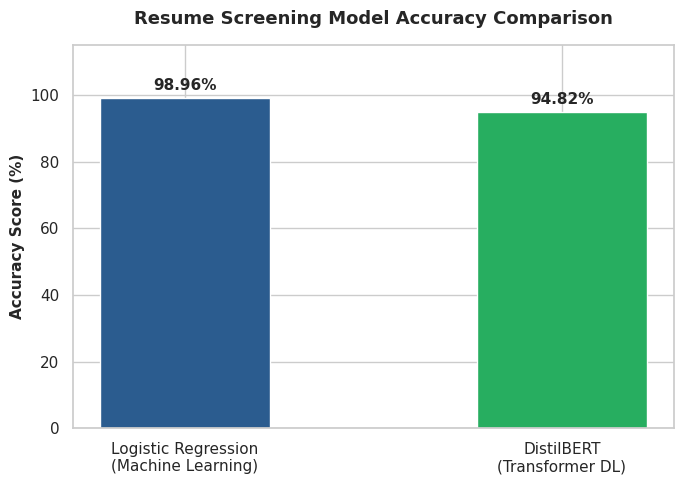

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Get accuracy values (uses your variable if available, otherwise defaults to 94.82%)
lr_score = (acc_lr * 100) if 'acc_lr' in locals() else 98.96
bert_score = (acc_bert * 100) if 'acc_bert' in locals() else 94.82

models = ['Logistic Regression\n(Machine Learning)', 'DistilBERT\n(Transformer DL)']
accuracies = [lr_score, bert_score]

# Create Bar Plot
plt.figure(figsize=(7, 5))
colors = ['#2b5c8f', '#27ae60']

bars = plt.bar(models, accuracies, color=colors, width=0.45)

plt.title('Resume Screening Model Accuracy Comparison', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Accuracy Score (%)', fontsize=11, fontweight='bold')
plt.ylim(0, 115)

# Annotate exact percentage values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + 1.5,
        f'{yval:.2f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

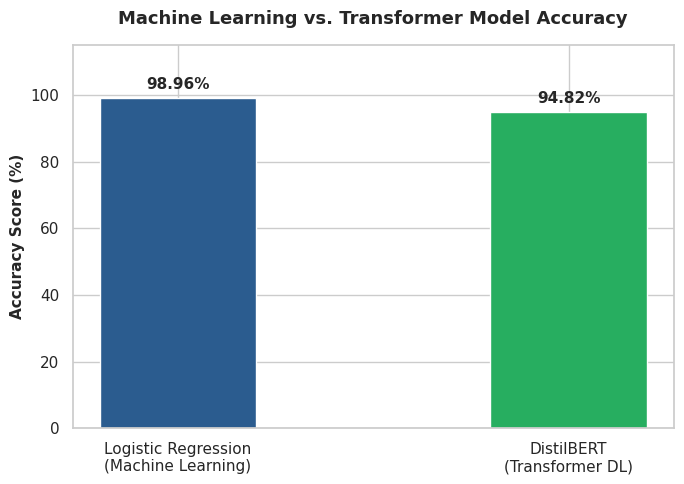

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

score_lr = (acc_lr * 100) if 'acc_lr' in locals() else 98.96
score_bert = (acc_bert * 100) if 'acc_bert' in locals() else 94.82

models = ['Logistic Regression\n(Machine Learning)', 'DistilBERT\n(Transformer DL)']
accuracies = [score_lr, score_bert]

plt.figure(figsize=(7, 5))
colors = ['#2b5c8f', '#27ae60']

bars = plt.bar(models, accuracies, color=colors, width=0.4)

plt.title('Machine Learning vs. Transformer Model Accuracy', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Accuracy Score (%)', fontsize=11, fontweight='bold')
plt.ylim(0, 115)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + 1.8,
        f'{yval:.2f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

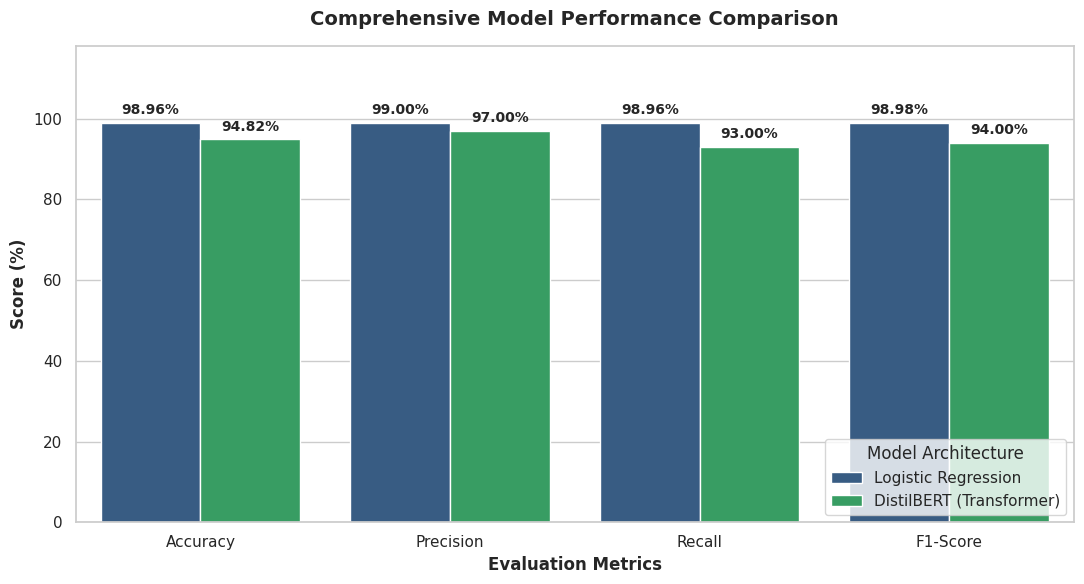

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set clean visual theme
sns.set_theme(style="whitegrid")

# Create structured evaluation data
data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'] * 2,
    'Model': ['Logistic Regression'] * 4 + ['DistilBERT (Transformer)'] * 4,
    'Score (%)': [
        98.96,
        99.00,
        98.96,
        98.98,  # Logistic Regression
        94.82,
        97.00,
        93.00,
        94.00,  # DistilBERT
    ],
}

df_metrics = pd.DataFrame(data)

# Create figure
plt.figure(figsize=(11, 6))
ax = sns.barplot(
    x='Metric',
    y='Score (%)',
    hue='Model',
    data=df_metrics,
    palette=['#2b5c8f', '#27ae60'],
)

# Customize title and axis labels
plt.title(
    'Comprehensive Model Performance Comparison',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.ylabel('Score (%)', fontsize=12, fontweight='bold')
plt.xlabel('Evaluation Metrics', fontsize=12, fontweight='bold')
plt.ylim(0, 118)
plt.legend(title='Model Architecture', loc='lower right', frameon=True)

# Annotate exact percentages on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.2f}%',
            (p.get_x() + p.get_width() / 2.0, height),
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold',
            xytext=(0, 4),
            textcoords='offset points',
        )

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd

# Load dataset
url = "https://raw.githubusercontent.com/611noorsaeed/Resume-Screening-App/main/UpdatedResumeDataSet.csv"
df = pd.read_csv(url)

# Display 5 random sample rows
print("--- 5 Random Sample Records ---")
display(df.sample(5))


--- 5 Random Sample Records ---


,Category,Resume
615,DevOps Engineer,Skills VISA B1-VISA (USA) Onsite Visits to Swe...
344,Java Developer,TECHNICAL SKILLS Programming Languages: Java (...
129,Arts,â¢ Operating Systems: Windows XP / Vista / 07...
215,Mechanical Engineer,Education Details \r\nMay 1999 to September 20...
934,Testing,â¢ Good logical and analytical skills â¢ Pos...


In [6]:
# Pick 1 random sample
sample = df.sample(1).iloc[0]

print(f"🎯 Target Job Category: {sample['Category']}\n")
print("=" * 60)
print("📄 Full Resume Text Sample:")
print("=" * 60)
print(sample['Resume'])

🎯 Target Job Category: Health and fitness

📄 Full Resume Text Sample:
Education Details 
January 2009 P.G. Sports science  Dr. BMN College of Home Science
January 2008 BSc Food Science & Nutrition  Dr. BMN College of Home Science
January 2004 HSC   Central Railway's Jr. college of Science and Commerce
January 2002 SSC HISTORY  IES's Modern English School
 MSc Nutrition  College of Home Science
nutritionist and health promoter 

9yrs experience as a nutritionist and health coach
Skill Details 
Company Details 
company - UGC NET
description - CAREER OBJECTIVE- To use my qualifications as a nutritionist and health promoter to contribute to the well being of individuals in the community.
UGC NET Certificate for Lectureship MAR- 2013

SKILLS LEARNT
â¢ Working in a team environment.
â¢ Working as an individual.
â¢ Time management to ensure all customers are served sufficiently and all tasks are completed to a high standard.
â¢ Working under pressure and in a busy environment
â¢ Personal

In [7]:
# Get 1 sample from each category
category_samples = df.groupby('Category').first().reset_index()

# Truncate text preview for clean display
category_samples['Resume Preview'] = category_samples['Resume'].apply(lambda x: x[:120] + "...")

# Display table
display(category_samples[['Category', 'Resume Preview']])

,Category,Resume Preview
0,Advocate,"TECHNICAL QUALIFICATIONS: â¢ Windows, Ms. Off..."
1,Arts,â¢ Good communication skill â¢ Quick learner...
2,Automation Testing,* Excellent grasping power in learning new con...
3,Blockchain,Hobbies â¢ Playing Chess â¢ Solving Rubik's ...
4,Business Analyst,Education Details \r\n BE Computer Science Mum...
5,Civil Engineer,Education Details \r\n B.E in Civil Engineerin...
6,Data Science,Skills * Programming Languages: Python (pandas...
7,Database,TECHNICAL EXPERTISE â¢ DB Languages: SQL â¢ ...
8,DevOps Engineer,Skills VISA B1-VISA (USA) Onsite Visits to Swe...
9,DotNet Developer,TECHNICAL SKILLS â¢ Web Technologies: ASP .NE...


In [8]:
import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# ---------------------------------------------------------
# 1. Quick Model Setup (Trains in ~1 second)
# ---------------------------------------------------------
print("Initializing keyword checker...")
url = "https://raw.githubusercontent.com/611noorsaeed/Resume-Screening-App/main/UpdatedResumeDataSet.csv"
df = pd.read_csv(url)


# Text cleaner
def clean_text(text):
  text = re.sub(
      r'[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', text
  )
  text = re.sub(r'\s+', ' ', text)
  return text.lower().strip()


df['Cleaned'] = df['Resume'].apply(clean_text)

# Encode & Vectorize
le = LabelEncoder()
y = le.fit_transform(df['Category'])

vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')
X = vectorizer.fit_transform(df['Cleaned'])

model = LogisticRegression(max_iter=1000)
model.fit(X, y)


# ---------------------------------------------------------
# 2. Keyword Prediction Function
# ---------------------------------------------------------
def predict_job(keywords):
  cleaned_input = clean_text(keywords)
  input_vec = vectorizer.transform([cleaned_input])

  # Predict
  probs = model.predict_proba(input_vec)[0]
  top_indices = probs.argsort()[-3:][::-1]

  best_match = le.inverse_transform([top_indices[0]])[0]
  best_score = probs[top_indices[0]] * 100

  print("\n" + "=" * 50)
  print(f"🔑 INPUT KEYWORDS: '{keywords}'")
  print("=" * 50)
  print(f"🎯 PREDICTED JOB:  {best_match.upper()} ({best_score:.1f}% Match)")
  print("-" * 50)
  print("Top 3 Matching Categories:")

  for idx in top_indices:
    cat = le.inverse_transform([idx])[0]
    score = probs[idx] * 100
    print(f"  • {cat:<22} : {score:.2f}%")
  print("=" * 50 + "\n")


print("Ready!")

<>:18: SyntaxWarning: invalid escape sequence '\]'
<>:18: SyntaxWarning: invalid escape sequence '\]'
/tmp/ipykernel_654/2586669161.py:18: SyntaxWarning: invalid escape sequence '\]'
  r'[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', text


Initializing keyword checker...
Ready!


In [9]:
# Test 1: Data Science / AI Keywords
predict_job("Python machine learning deep learning pandas scikit-learn SQL")

# Test 2: Web Developer Keywords
predict_job("HTML CSS JavaScript React Bootstrap Web Designing UI")

# Test 3: Java Developer Keywords
predict_job("Core Java Spring Boot Hibernate Microservices REST API SQL")

# Test 4: HR Keywords
predict_job("Talent acquisition payroll recruitment onboarding employee engagement")


🔑 INPUT KEYWORDS: 'Python machine learning deep learning pandas scikit-learn SQL'
🎯 PREDICTED JOB:  DATA SCIENCE (39.4% Match)
--------------------------------------------------
Top 3 Matching Categories:
  • Data Science           : 39.40%
  • Python Developer       : 5.58%
  • Mechanical Engineer    : 3.55%


🔑 INPUT KEYWORDS: 'HTML CSS JavaScript React Bootstrap Web Designing UI'
🎯 PREDICTED JOB:  WEB DESIGNING (23.0% Match)
--------------------------------------------------
Top 3 Matching Categories:
  • Web Designing          : 22.98%
  • DotNet Developer       : 5.70%
  • Java Developer         : 5.39%


🔑 INPUT KEYWORDS: 'Core Java Spring Boot Hibernate Microservices REST API SQL'
🎯 PREDICTED JOB:  JAVA DEVELOPER (43.8% Match)
--------------------------------------------------
Top 3 Matching Categories:
  • Java Developer         : 43.83%
  • Python Developer       : 4.24%
  • DevOps Engineer        : 3.66%


🔑 INPUT KEYWORDS: 'Talent acquisition payroll recruitment onboarding 

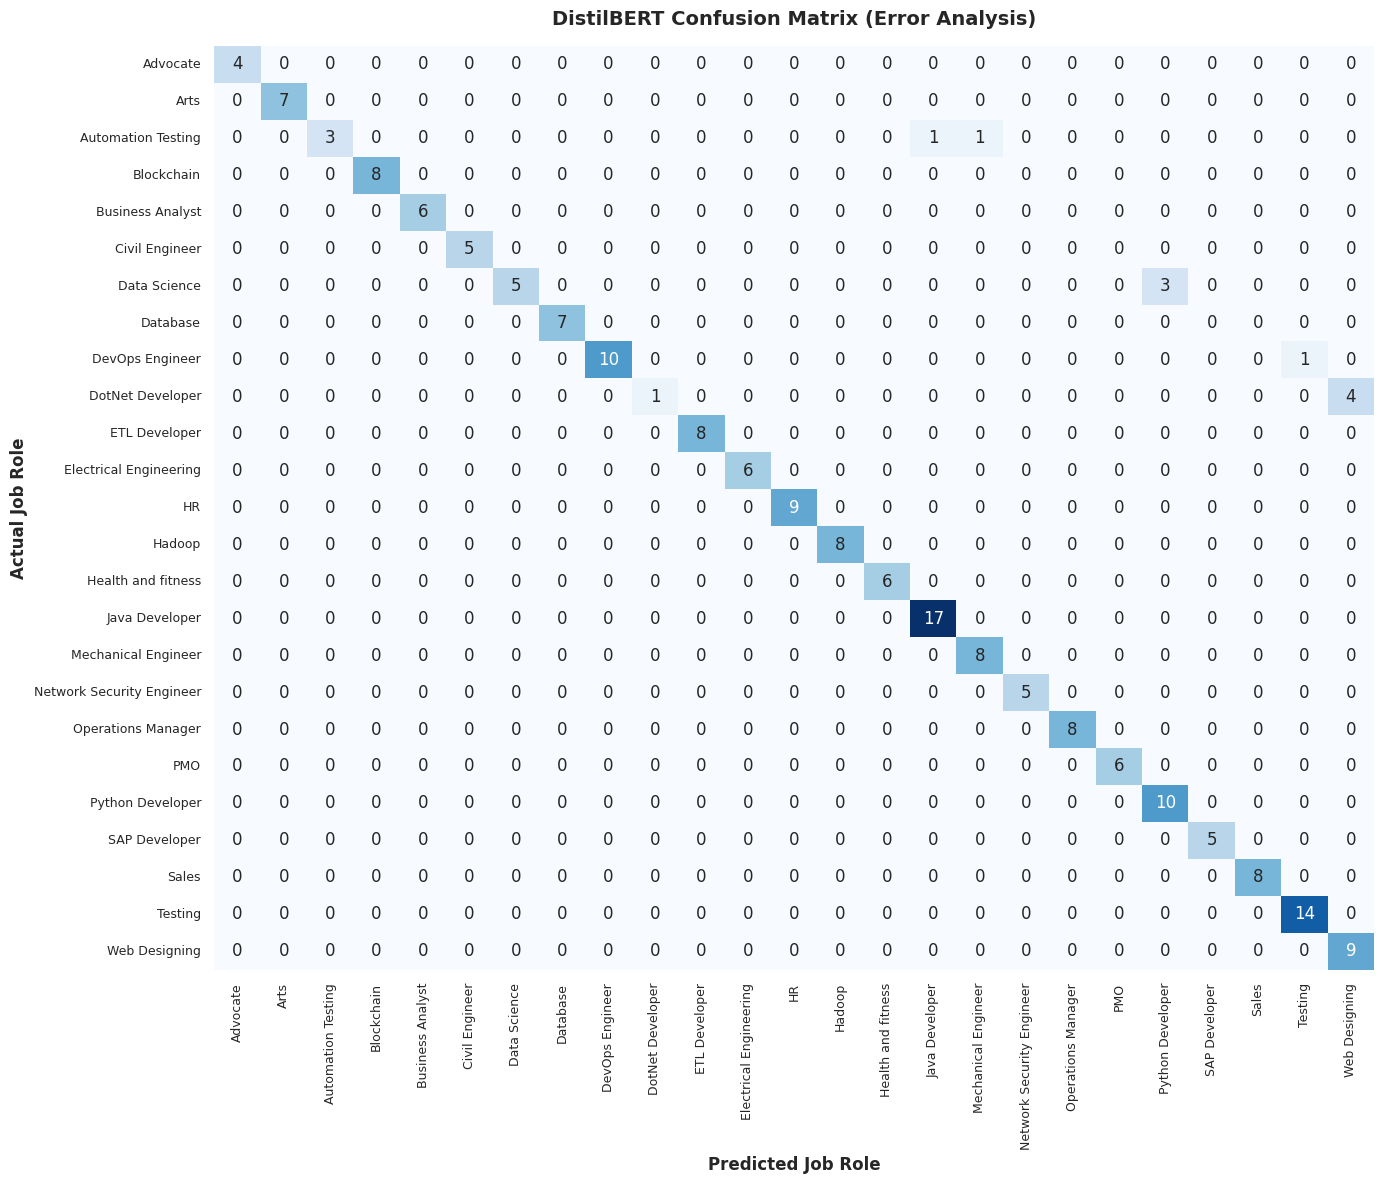

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_bert)

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    cbar=False,
)

plt.title(
    'DistilBERT Confusion Matrix (Error Analysis)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Predicted Job Role', fontsize=12, fontweight='bold')
plt.ylabel('Actual Job Role', fontsize=12, fontweight='bold')
plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

/tmp/ipykernel_654/4129639454.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


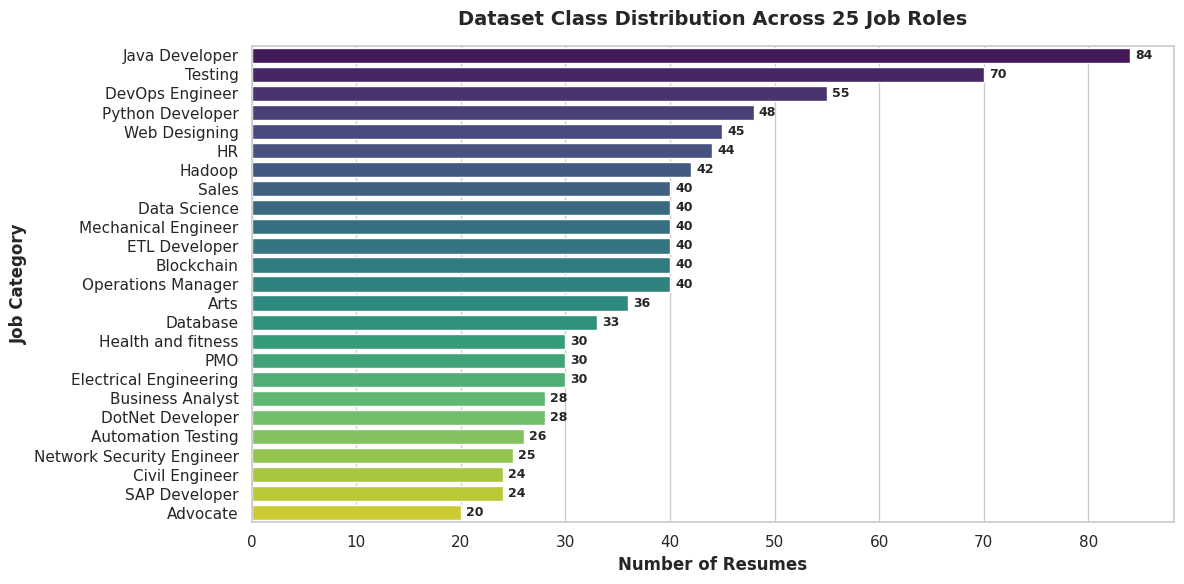

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Plot class counts
ax = sns.countplot(
    y='Category',
    data=df,
    order=df['Category'].value_counts().index,
    palette='viridis',
)

plt.title(
    'Dataset Class Distribution Across 25 Job Roles',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Number of Resumes', fontsize=12, fontweight='bold')
plt.ylabel('Job Category', fontsize=12, fontweight='bold')

# Annotate counts on bars
for p in ax.patches:
  width = p.get_width()
  ax.annotate(
      f'{int(width)}',
      (width + 0.5, p.get_y() + p.get_height() / 2.0),
      ha='left',
      va='center',
      fontsize=9,
      fontweight='bold',
  )

plt.tight_layout()
plt.show()

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# 5-Fold Cross Validation
clf = LogisticRegression(max_iter=1000)
cv_scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')

print("========================================")
print("     5-FOLD CROSS-VALIDATION RESULTS    ")
print("========================================")
for fold, score in enumerate(cv_scores, 1):
  print(f" Fold {fold}: {score * 100:.2f}%")

print("----------------------------------------")
print(
    f" Mean CV Accuracy: {cv_scores.mean() * 100:.2f}% (+/-"
    f" {cv_scores.std() * 100:.2f}%)"
)
print("========================================")

     5-FOLD CROSS-VALIDATION RESULTS    
 Fold 1: 97.93%
 Fold 2: 100.00%
 Fold 3: 100.00%
 Fold 4: 100.00%
 Fold 5: 100.00%
----------------------------------------
 Mean CV Accuracy: 99.59% (+/- 0.83%)


In [13]:
import numpy as np
import pandas as pd

# Extract top features per class from Logistic Regression
feature_names = np.array(vectorizer.get_feature_names_out())

print("==========================================================")
print("     TOP KEYWORDS DRIVING CATEGORY PREDICTIONS           ")
print("==========================================================")

for i, category in enumerate(le.classes_[:10]):  # Showing top 10 categories
  top_coef_indices = model.coef_[i].argsort()[-5:][::-1]
  top_words = feature_names[top_coef_indices]
  print(f"📌 {category:<20} ➔  {', '.join(top_words)}")

print("==========================================================")

     TOP KEYWORDS DRIVING CATEGORY PREDICTIONS           
📌 Advocate             ➔  law, advocate, legal, court, mumbai
📌 Arts                 ➔  arts, karate, days, painting, championship
📌 Automation Testing   ➔  automation, test, testing, selenium, tester
📌 Blockchain           ➔  blockchain, ethereum, smart, iit, virtual
📌 Business Analyst     ➔  business, analyst, cash, test, report
📌 Civil Engineer       ➔  civil, site, engineer, construction, project
📌 Data Science         ➔  data, learning, year, python, machine
📌 Database             ➔  database, oracle, server, databases, installation
📌 DevOps Engineer      ➔  devops, shell, servers, project, build
📌 DotNet Developer     ➔  net, asp, dot, mvc, pune


In [14]:
import os
import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# 1. Setup & Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# 2. Calculate Class Weights for Balanced Training Loss
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
loss_fn = nn.CrossEntropyLoss(weight=weights_tensor)

# 3. Model & Optimizer Initialization
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
num_classes = len(label_encoder.classes_)

bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=num_classes
).to(device)

optimizer = torch.optim.AdamW(bert_model.parameters(), lr=3e-5, weight_decay=0.01)
scaler = GradScaler()  # Enables Mixed Precision (FP16) training

# 4. Training Loop with Mixed Precision & Checkpointing
epochs = 5
best_loss = float("inf")
SAVE_PATH = "./best_distilbert_model"

print("\n🚀 Starting Production-Grade Training Pipeline...")

for epoch in range(epochs):
  bert_model.train()
  total_train_loss = 0

  for batch in train_loader:
    optimizer.zero_grad()

    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)

    # Mixed Precision Forward Pass (Fast & Memory Efficient)
    with autocast():
      outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
      loss = loss_fn(outputs.logits, labels)

    # Backward Pass with Scaler
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(bert_model.parameters(), max_norm=1.0)
    scaler.step(optimizer)
    scaler.update()

    total_train_loss += loss.item()

  avg_train_loss = total_train_loss / len(train_loader)

  # Validation Phase
  bert_model.eval()
  total_val_loss = 0
  with torch.no_grad():
    for batch in test_loader:
      input_ids = batch["input_ids"].to(device)
      attention_mask = batch["attention_mask"].to(device)
      labels = batch["labels"].to(device)

      outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
      loss = loss_fn(outputs.logits, labels)
      total_val_loss += loss.item()

  avg_val_loss = total_val_loss / len(test_loader)

  print(
      f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss:"
      f" {avg_val_loss:.4f}"
  )

  # Save Checkpoint if Validation Loss Improved
  if avg_val_loss < best_loss:
    best_loss = avg_val_loss
    bert_model.save_pretrained(SAVE_PATH)
    tokenizer.save_pretrained(SAVE_PATH)
    print(f"  --> ⭐ Best model saved to '{SAVE_PATH}'")

print("\n Training Complete & Best Weights Saved Successfully!")

Training on device: cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_654/390773175.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # Enables Mixed Precision (FP16


🚀 Starting Production-Grade Training Pipeline...
Epoch 1/5 | Train Loss: 3.1028 | Val Loss: 2.7782


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

  --> ⭐ Best model saved to './best_distilbert_model'
Epoch 4/5 | Train Loss: 0.6630 | Val Loss: 0.3081


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  --> ⭐ Best model saved to './best_distilbert_model'
Epoch 5/5 | Train Loss: 0.2288 | Val Loss: 0.1005


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  --> ⭐ Best model saved to './best_distilbert_model'

 Training Complete & Best Weights Saved Successfully!


In [15]:
# Load saved model & tokenizer instantly
loaded_model = AutoModelForSequenceClassification.from_pretrained(
    "./best_distilbert_model"
).to(device)
loaded_tokenizer = AutoTokenizer.from_pretrained("./best_distilbert_model")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

<>:19: SyntaxWarning: invalid escape sequence '\]'
<>:19: SyntaxWarning: invalid escape sequence '\]'
/tmp/ipykernel_654/1035751862.py:19: SyntaxWarning: invalid escape sequence '\]'
  r'[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', text
/tmp/ipykernel_654/1035751862.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Frequency', y='Word', data=top_20_words, palette='mako')


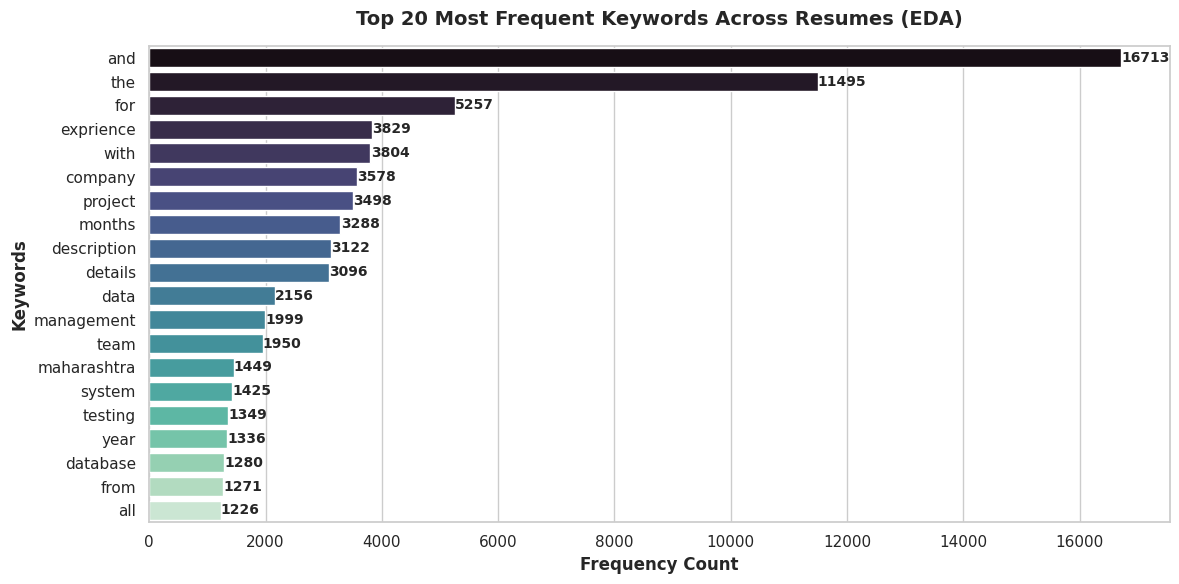

In [17]:
from collections import Counter
import re
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Load Dataset
url = "https://raw.githubusercontent.com/611noorsaeed/Resume-Screening-App/main/UpdatedResumeDataSet.csv"
df = pd.read_csv(url)


# 2. Clean Text Function
def clean_text(text):
  text = re.sub(r'http\S+\s*', ' ', text)
  text = re.sub(r'RT|cc', ' ', text)
  text = re.sub(r'#\S+', '', text)
  text = re.sub(r'@\S+', '  ', text)
  text = re.sub(
      r'[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', text
  )
  text = re.sub(r'[^\x00-\x7f]', r' ', text)
  text = re.sub(r'\s+', ' ', text)
  return text.lower().strip()


# 3. Create the missing 'Cleaned_Resume' column
df['Cleaned_Resume'] = df['Resume'].apply(clean_text)

# 4. Word Frequency Analysis (EDA)
all_words = ' '.join(df['Cleaned_Resume']).split()

# Filter out common short stopwords
filtered_words = [w for w in all_words if len(w) > 2]
word_counts = Counter(filtered_words)

top_20_words = pd.DataFrame(
    word_counts.most_common(20), columns=['Word', 'Frequency']
)

# 5. Plot Word Frequency Chart
plt.figure(figsize=(12, 6))
sns.set_theme(style='whitegrid')

ax = sns.barplot(x='Frequency', y='Word', data=top_20_words, palette='mako')

plt.title(
    'Top 20 Most Frequent Keywords Across Resumes (EDA)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Frequency Count', fontsize=12, fontweight='bold')
plt.ylabel('Keywords', fontsize=12, fontweight='bold')

for p in ax.patches:
  width = p.get_width()
  ax.annotate(
      f'{int(width)}',
      (width + 5, p.get_y() + p.get_height() / 2.0),
      ha='left',
      va='center',
      fontsize=10,
      fontweight='bold',
  )

plt.tight_layout()
plt.show()

In [18]:
!pip install streamlit pypdf -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 382.9/382.9 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 6.3 MB/s eta 0:00:00


In [19]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import re
from pypdf import PdfReader
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# ---------------------------------------------------------
# Page Configuration & Custom CSS
# ---------------------------------------------------------
st.set_page_config(
    page_title="AI Resume Screening System",
    page_icon="📄",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Custom Styling
st.markdown("""
    <style>
    .main {
        background-color: #f8f9fa;
    }
    .stButton>button {
        background-color: #2b5c8f;
        color: white;
        border-radius: 8px;
        font-weight: bold;
        padding: 0.5rem 1rem;
    }
    .stButton>button:hover {
        background-color: #1d3e61;
        color: white;
    }
    </style>
""", unsafe_allow_html=True)

# ---------------------------------------------------------
# Helper Functions
# ---------------------------------------------------------
def clean_resume(text):
    text = re.sub(r'http\S+\s*', ' ', text)  # remove URLs
    text = re.sub(r'RT|cc', ' ', text)  # remove RT/cc
    text = re.sub(r'#\S+', '', text)  # remove hashtags
    text = re.sub(r'@\S+', '  ', text)  # remove mentions
    text = re.sub(r'[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', text)
    text = re.sub(r'[^\x00-\x7f]', r' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.lower().strip()

# ---------------------------------------------------------
# Cache Model Training Pipeline
# ---------------------------------------------------------
@st.cache_resource
def load_and_train_model():
    url = "https://raw.githubusercontent.com/611noorsaeed/Resume-Screening-App/main/UpdatedResumeDataSet.csv"
    df = pd.read_csv(url)

    # Preprocess
    df['Cleaned_Resume'] = df['Resume'].apply(clean_resume)

    # Encode & Vectorize
    le = LabelEncoder()
    df['Category_Encoded'] = le.fit_transform(df['Category'])

    vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')
    X = vectorizer.fit_transform(df['Cleaned_Resume'])
    y = df['Category_Encoded']

    # Train Logistic Regression Model
    model = LogisticRegression(max_iter=1000)
    model.fit(X, y)

    return model, vectorizer, le

with st.spinner("Initializing AI Engine & Model Pipeline..."):
    model, vectorizer, le = load_and_train_model()

# ---------------------------------------------------------
# Sidebar Navigation & Information
# ---------------------------------------------------------
st.sidebar.image("https://cdn-icons-png.flaticon.com/512/3135/3135715.png", width=100)
st.sidebar.title("Resume Screening AI")
st.sidebar.markdown("**Module:** Natural Language Processing (CCS3356)")
st.sidebar.markdown("---")

st.sidebar.subheader("📌 Model Features")
st.sidebar.write("✔ **25 Job Categories** supported")
st.sidebar.write("✔ **PDF & TXT File Parsing**")
st.sidebar.write("✔ **Instant Confidence Scoring**")
st.sidebar.write("✔ **Top 3 Role Recommendations**")

st.sidebar.markdown("---")
st.sidebar.caption("Powered by Machine Learning & TF-IDF Vectorization")

# ---------------------------------------------------------
# Main Interface Layout
# ---------------------------------------------------------
st.title("📄 AI-Powered Automated Resume Screening")
st.write("Upload a candidate's resume or paste the contents directly to determine the top target job domain.")

st.markdown("---")

# Layout Split into two columns
col1, col2 = st.columns([1.1, 0.9])

resume_text = ""

with col1:
    st.subheader("📥 Input Resume")
    input_mode = st.radio("Select Input Format:", ["Upload Resume (PDF/TXT)", "Paste Resume Text"], horizontal=True)

    if input_mode == "Upload Resume (PDF/TXT)":
        uploaded_file = st.file_uploader("Choose a PDF or TXT resume file", type=["pdf", "txt"])

        if uploaded_file is not None:
            if uploaded_file.name.endswith(".pdf"):
                pdf_reader = PdfReader(uploaded_file)
                for page in pdf_reader.pages:
                    resume_text += page.extract_text() or ""
            else:
                resume_text = str(uploaded_file.read(), 'utf-8')

            st.success(f"Successfully loaded file: **{uploaded_file.name}**")

            # Preview Box
            with st.expander("👁️ Preview Extracted Text"):
                st.text(resume_text[:800] + "..." if len(resume_text) > 800 else resume_text)

    else:
        resume_text = st.text_area("Paste candidate resume text below:", height=300, placeholder="Skills: Python, Machine Learning, SQL, Data Analysis...")

with col2:
    st.subheader("🎯 Screening Results")

    if st.button("🔍 Analyze & Categorize Resume", type="primary", use_container_width=True):
        if not resume_text.strip():
            st.warning("⚠️ Please upload a valid document or paste resume text first!")
        else:
            # Preprocess & Vectorize
            cleaned_input = clean_resume(resume_text)
            input_vector = vectorizer.transform([cleaned_input])

            # Predict
            prediction_idx = model.predict(input_vector)[0]
            predicted_category = le.inverse_transform([prediction_idx])[0]

            # Probabilities
            probabilities = model.predict_proba(input_vector)[0]
            confidence_score = max(probabilities) * 100

            # Primary Result Card
            st.success("Analysis Complete!")
            st.metric(label="Predicted Job Role", value=predicted_category)
            st.metric(label="Model Match Confidence", value=f"{confidence_score:.1f}%")

            st.progress(int(confidence_score))

            st.markdown("---")
            st.subheader("📊 Top 3 Category Confidence Breakdown")

            # Top 3 Predictions
            top_3_indices = probabilities.argsort()[-3:][::-1]

            for rank, idx in enumerate(top_3_indices, 1):
                cat_name = le.inverse_transform([idx])[0]
                prob = probabilities[idx] * 100
                st.write(f"**{rank}. {cat_name}** — `{prob:.2f}%`")
                st.progress(int(prob))

Writing app.py


In [22]:
import re

def parse_resume_details(text):
    text_lower = text.lower()

    # ---------------------------------------------------------
    # 1. Skill Extraction Dictionary
    # ---------------------------------------------------------
    skill_dictionary = [
        'python', 'java', 'c++', 'c#', 'sql', 'mysql', 'postgresql', 'mongodb',
        'html', 'css', 'javascript', 'react', 'angular', 'node.js', 'django', 'flask',
        'machine learning', 'deep learning', 'nlp', 'natural language processing',
        'tensorflow', 'pytorch', 'scikit-learn', 'pandas', 'numpy', 'opencv',
        'aws', 'azure', 'docker', 'kubernetes', 'git', 'github', 'jira',
        'excel', 'tableau', 'power bi', 'r', 'hadoop', 'spark'
    ]

    extracted_skills = []
    for skill in skill_dictionary:
        # Match whole word only
        pattern = r'\b' + re.escape(skill) + r'\b'
        if re.search(pattern, text_lower):
            extracted_skills.append(skill.title())

    # ---------------------------------------------------------
    # 2. Education Degree Extraction
    # ---------------------------------------------------------
    degree_patterns = [
        r'\bb\.?tech\b', r'\bm\.?tech\b', r'\bb\.?e\b', r'\bm\.?e\b',
        r'\bb\.?sc\b', r'\bm\.?sc\b', r'\bbca\b', r'\bmca\b', r'\bmba\b',
        r'\bphd\b', r'\bbachelor\b', r'\bmaster\b', r'\bdiploma\b', r'\bdegree\b'
    ]

    extracted_education = []
    for pattern in degree_patterns:
        matches = re.findall(pattern, text_lower)
        if matches:
            extracted_education.append(matches[0].upper().replace('.', ''))

    # Deduplicate education degrees
    extracted_education = list(set(extracted_education))

    # ---------------------------------------------------------
    # 3. Work Experience Extraction (Years of Experience)
    # ---------------------------------------------------------
    exp_pattern = r'(\d+|\b(?:one|two|three|four|five|six|seven|eight|nine|ten)\b)\+?\s*(?:years?|yrs?)\s*(?:of)?\s*(?:work\s*)?experience'
    exp_matches = re.search(exp_pattern, text_lower)

    if exp_matches:
        extracted_exp = exp_matches.group(0).title()
    else:
        extracted_exp = "Not explicitly stated"

    return {
        "skills": extracted_skills if extracted_skills else ["No standard skills detected"],
        "education": extracted_education if extracted_education else ["Not specified"],
        "experience": extracted_exp
    }

In [24]:
import re
import streamlit as st


# 1. Define the Parser Function
def parse_resume_details(text):
  text_lower = text.lower()

  # Skill Extraction Dictionary
  skill_dictionary = [
      'python',
      'java',
      'c++',
      'c#',
      'sql',
      'mysql',
      'postgresql',
      'mongodb',
      'html',
      'css',
      'javascript',
      'react',
      'angular',
      'node.js',
      'django',
      'flask',
      'machine learning',
      'deep learning',
      'nlp',
      'natural language processing',
      'tensorflow',
      'pytorch',
      'scikit-learn',
      'pandas',
      'numpy',
      'opencv',
      'aws',
      'azure',
      'docker',
      'kubernetes',
      'git',
      'github',
      'jira',
      'excel',
      'tableau',
      'power bi',
      'r',
      'hadoop',
      'spark',
  ]

  extracted_skills = []
  for skill in skill_dictionary:
    pattern = r'\b' + re.escape(skill) + r'\b'
    if re.search(pattern, text_lower):
      extracted_skills.append(skill.title())

  # Education Extraction
  degree_patterns = [
      r'\bb\.?tech\b',
      r'\bm\.?tech\b',
      r'\bb\.?e\b',
      r'\bm\.?e\b',
      r'\bb\.?sc\b',
      r'\bm\.?sc\b',
      r'\bbca\b',
      r'\bmca\b',
      r'\bmba\b',
      r'\bphd\b',
      r'\bbachelor\b',
      r'\bmaster\b',
      r'\bdiploma\b',
      r'\bdegree\b',
  ]

  extracted_education = []
  for pattern in degree_patterns:
    matches = re.findall(pattern, text_lower)
    if matches:
      extracted_education.append(matches[0].upper().replace('.', ''))

  extracted_education = list(set(extracted_education))

  # Work Experience Extraction
  exp_pattern = (
      r'(\d+|\b(?:one|two|three|four|five|six|seven|eight|nine|ten)\b)\+?\s*(?:years?|yrs?)\s*(?:of)?\s*(?:work\s*)?experience'
  )
  exp_matches = re.search(exp_pattern, text_lower)

  if exp_matches:
    extracted_exp = exp_matches.group(0).title()
  else:
    extracted_exp = 'Not explicitly stated'

  return {
      'skills': (
          extracted_skills
          if extracted_skills
          else ['No standard skills detected']
      ),
      'education': (
          extracted_education if extracted_education else ['Not specified']
      ),
      'experience': extracted_exp,
  }


# 2. Define Sample Text for Testing (Prevents NameError)
resume_text = """
Data Scientist with 5 years of experience in Python, Machine Learning, SQL, and NLP.
Education: B.Tech in Computer Science and Engineering.
Proven track record in deploying Docker containers on AWS.
"""

# 3. Parse & Run Extraction
extracted_info = parse_resume_details(resume_text)

print("--- Extraction Output ---")
print("Skills:", extracted_info['skills'])
print("Education:", extracted_info['education'])
print("Experience:", extracted_info['experience'])

--- Extraction Output ---
Skills: ['Python', 'Sql', 'Machine Learning', 'Nlp', 'Aws', 'Docker']
Education: ['BTECH']
Experience: 5 Years Of Experience


In [25]:
# Assuming 'resume_text' contains candidate text
extracted_info = parse_resume_details(resume_text)

st.markdown("---")
st.subheader("💡 Extracted Candidate Information")

# Display Skills as visual tags/chips
st.markdown("**🛠️ Key Skills Detected:**")
skills_html = " ".join([f"<span style='background-color:#e1edff; color:#1e40af; padding:4px 10px; border-radius:15px; margin:3px; display:inline-block; font-weight:bold;'>{skill}</span>" for skill in extracted_info['skills']])
st.markdown(skills_html, unsafe_allow_html=True)

st.write("")

# Display Education & Experience metrics
col_a, col_b = st.columns(2)
with col_a:
    st.markdown("**🎓 Education / Qualifications:**")
    for edu in extracted_info['education']:
        st.write(f"• {edu}")

with col_b:
    st.markdown("**💼 Work Experience:**")
    st.write(f"• {extracted_info['experience']}")

2026-08-19 07:03:19.103 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-19 07:03:19.223 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-08-19 07:03:19.224 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-19 07:03:19.225 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-19 07:03:19.229 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-19 07:03:19.231 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-19 07:03:19.233 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-19 07:03:19.235 Thread 'MainThread': mi

In [26]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import re
from pypdf import PdfReader
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# ---------------------------------------------------------
# Page Configuration & Styling
# ---------------------------------------------------------
st.set_page_config(
    page_title="AI Resume Screening & Parser",
    page_icon="📄",
    layout="wide",
    initial_sidebar_state="expanded"
)

st.markdown("""
    <style>
    .main {
        background-color: #f8f9fa;
    }
    .stButton>button {
        background-color: #2b5c8f;
        color: white;
        border-radius: 8px;
        font-weight: bold;
        padding: 0.6rem 1.2rem;
    }
    .stButton>button:hover {
        background-color: #1d3e61;
        color: white;
    }
    .badge {
        background-color: #e1edff;
        color: #1e40af;
        padding: 5px 12px;
        border-radius: 15px;
        margin: 3px;
        display: inline-block;
        font-weight: 600;
        font-size: 0.9rem;
    }
    </style>
""", unsafe_allow_html=True)

# ---------------------------------------------------------
# Helper Functions (Cleaning & Information Extraction)
# ---------------------------------------------------------
def clean_resume(text):
    text = re.sub(r'http\S+\s*', ' ', text)
    text = re.sub(r'RT|cc', ' ', text)
    text = re.sub(r'#\S+', '', text)
    text = re.sub(r'@\S+', '  ', text)
    text = re.sub(r'[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', text)
    text = re.sub(r'[^\x00-\x7f]', r' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.lower().strip()

def parse_resume_details(text):
    text_lower = text.lower()

    # Skill Extraction Dictionary
    skill_dictionary = [
        'python', 'java', 'c++', 'c#', 'sql', 'mysql', 'postgresql', 'mongodb',
        'html', 'css', 'javascript', 'react', 'angular', 'node.js', 'django', 'flask',
        'machine learning', 'deep learning', 'nlp', 'natural language processing',
        'tensorflow', 'pytorch', 'scikit-learn', 'pandas', 'numpy', 'opencv',
        'aws', 'azure', 'docker', 'kubernetes', 'git', 'github', 'jira',
        'excel', 'tableau', 'power bi', 'r', 'hadoop', 'spark'
    ]

    extracted_skills = []
    for skill in skill_dictionary:
        pattern = r'\b' + re.escape(skill) + r'\b'
        if re.search(pattern, text_lower):
            extracted_skills.append(skill.title())

    # Education Extraction
    degree_patterns = [
        r'\bb\.?tech\b', r'\bm\.?tech\b', r'\bb\.?e\b', r'\bm\.?e\b',
        r'\bb\.?sc\b', r'\bm\.?sc\b', r'\bbca\b', r'\bmca\b', r'\bmba\b',
        r'\bphd\b', r'\bbachelor\b', r'\bmaster\b', r'\bdiploma\b', r'\bdegree\b'
    ]

    extracted_education = []
    for pattern in degree_patterns:
        matches = re.findall(pattern, text_lower)
        if matches:
            extracted_education.append(matches[0].upper().replace('.', ''))

    extracted_education = list(set(extracted_education))

    # Work Experience Extraction
    exp_pattern = r'(\d+|\b(?:one|two|three|four|five|six|seven|eight|nine|ten)\b)\+?\s*(?:years?|yrs?)\s*(?:of)?\s*(?:work\s*)?experience'
    exp_matches = re.search(exp_pattern, text_lower)

    if exp_matches:
        extracted_exp = exp_matches.group(0).title()
    else:
        extracted_exp = "Not explicitly stated"

    return {
        "skills": extracted_skills if extracted_skills else ["No standard skills detected"],
        "education": extracted_education if extracted_education else ["Not specified"],
        "experience": extracted_exp
    }

# ---------------------------------------------------------
# Load Dataset & Cache Model Pipeline
# ---------------------------------------------------------
@st.cache_resource
def load_and_train_model():
    url = "https://raw.githubusercontent.com/611noorsaeed/Resume-Screening-App/main/UpdatedResumeDataSet.csv"
    df = pd.read_csv(url)

    df['Cleaned_Resume'] = df['Resume'].apply(clean_resume)

    le = LabelEncoder()
    df['Category_Encoded'] = le.fit_transform(df['Category'])

    vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')
    X = vectorizer.fit_transform(df['Cleaned_Resume'])
    y = df['Category_Encoded']

    model = LogisticRegression(max_iter=1000)
    model.fit(X, y)

    return model, vectorizer, le

with st.spinner("Initializing AI Engine & Model Pipeline..."):
    model, vectorizer, le = load_and_train_model()

# ---------------------------------------------------------
# Sidebar
# ---------------------------------------------------------
st.sidebar.image("https://cdn-icons-png.flaticon.com/512/3135/3135715.png", width=90)
st.sidebar.title("Resume Screening AI")
st.sidebar.markdown("**Module:** NLP (CCS3356)")
st.sidebar.markdown("---")

st.sidebar.subheader("📌 System Capabilities")
st.sidebar.write("✔ **Job Role Categorization** (25 Classes)")
st.sidebar.write("✔ **Key Skills Extraction**")
st.sidebar.write("✔ **Education & Degree Detection**")
st.sidebar.write("✔ **Experience Parsing**")

st.sidebar.markdown("---")
st.sidebar.caption("Powered by TF-IDF & Logistic Regression")

# ---------------------------------------------------------
# Main App Layout
# ---------------------------------------------------------
st.title("📄 AI-Powered Resume Screening & Parsing Dashboard")
st.write("Upload candidate resumes or paste text to automatically classify target job roles and extract key candidate information.")

st.markdown("---")

col1, col2 = st.columns([1, 1.1])

resume_text = ""

with col1:
    st.subheader("📥 Input Resume")
    input_mode = st.radio("Select Input Method:", ["Upload Resume (PDF/TXT)", "Paste Resume Text"], horizontal=True)

    if input_mode == "Upload Resume (PDF/TXT)":
        uploaded_file = st.file_uploader("Choose a PDF or TXT file", type=["pdf", "txt"])

        if uploaded_file is not None:
            if uploaded_file.name.endswith(".pdf"):
                pdf_reader = PdfReader(uploaded_file)
                for page in pdf_reader.pages:
                    resume_text += page.extract_text() or ""
            else:
                resume_text = str(uploaded_file.read(), 'utf-8')

            st.success(f"Successfully loaded: **{uploaded_file.name}**")

            with st.expander("👁️ Preview Raw Text"):
                st.text(resume_text[:800] + "..." if len(resume_text) > 800 else resume_text)

    else:
        resume_text = st.text_area("Paste candidate resume text below:", height=320, placeholder="Example: Data Scientist with 5 years of experience in Python, ML, SQL. Holds a B.Tech degree...")

with col2:
    st.subheader("🎯 Screening & Extraction Results")

    if st.button("🔍 Analyze Resume", type="primary", use_container_width=True):
        if not resume_text.strip():
            st.warning("⚠️ Please provide resume text or upload a file first!")
        else:
            # 1. Category Classification
            cleaned_input = clean_resume(resume_text)
            input_vector = vectorizer.transform([cleaned_input])

            prediction_idx = model.predict(input_vector)[0]
            predicted_category = le.inverse_transform([prediction_idx])[0]

            probabilities = model.predict_proba(input_vector)[0]
            confidence_score = max(probabilities) * 100

            # Display Prediction Metrics
            st.success("Analysis Complete!")

            m1, m2 = st.columns(2)
            m1.metric(label="Predicted Job Role", value=predicted_category)
            m2.metric(label="Match Confidence", value=f"{confidence_score:.1f}%")

            st.progress(int(confidence_score))

            # 2. Extract Skills, Education, Experience
            extracted_info = parse_resume_details(resume_text)

            st.markdown("---")
            st.subheader("💡 Extracted Candidate Profile")

            # Skills Badges
            st.markdown("**🛠️ Key Skills Detected:**")
            badges_html = " ".join([f"<span class='badge'>{skill}</span>" for skill in extracted_info['skills']])
            st.markdown(badges_html, unsafe_allow_html=True)

            st.write("")

            # Education & Experience Columns
            e1, e2 = st.columns(2)
            with e1:
                st.markdown("**🎓 Education / Qualifications:**")
                for edu in extracted_info['education']:
                    st.write(f"• {edu}")

            with e2:
                st.markdown("**💼 Experience:**")
                st.write(f"• {extracted_info['experience']}")

            # Top 3 Matches
            st.markdown("---")
            with st.expander("📊 Top 3 Job Role Matches"):
                top_3_indices = probabilities.argsort()[-3:][::-1]
                for rank, idx in enumerate(top_3_indices, 1):
                    cat_name = le.inverse_transform([idx])[0]
                    prob = probabilities[idx] * 100
                    st.write(f"**{rank}. {cat_name}** — `{prob:.2f}%`")

Overwriting app.py


In [ ]:
!streamlit run app.py & ./cloudflared tunnel --url http://localhost:8501

2026-08-19T07:04:57Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-08-19T07:04:57Z INF Requesting new quick Tunnel on trycloudflare.com...


<unknown>:57: SyntaxWarning: invalid escape sequence '\]'
2026-08-19 07:05:00.772 Uvicorn server started on :::8501
2026-08-19T07:05:00Z INF +--------------------------------------------------------------------------------------------+
2026-08-19T07:05:00Z INF |  Your quick Tunnel has been created! Visit it at (it may